In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import nibabel as nib
import json
from pathlib import Path

In [5]:
TARGET_CATEGORIES = {"2c", "2d"}

with open("/home/chest_ct/code/data/rexgrounding-ct/dataset.json", "r") as f:
    data = json.load(f)

filtered_data = {}

for split in ["train", "val", "test"]:
    filtered_data[split] = []

    for sample in data.get(split, []):

        categories = sample.get("categories", {})

        keep_keys = [
            k for k, v in categories.items()
            if v in TARGET_CATEGORIES
        ]

        # Skip studies with no 2c/2d findings
        if not keep_keys:
            continue

        new_sample = sample.copy()

        # Filter only fields that exist
        for field in ["findings", "entity_counts", "pixels", "categories"]:
            if field in sample:
                new_sample[field] = {
                    k: sample[field][k]
                    for k in keep_keys
                    if k in sample[field]
                }

        filtered_data[split].append(new_sample)

with open("C:\\Users\\chamu\\D\\UOR\\FYP\\fyp\\data\\rexgrounding-ct\\dataset_2.json", "w") as f:
    json.dump(filtered_data, f, indent=4)

In [6]:
from collections import defaultdict

stats = defaultdict(int)

for split in ["train", "val", "test"]:
    split_stats = {"2c_only": 0, "2d_only": 0, "both": 0}

    for sample in data.get(split, []):
        categories = set(sample.get("categories", {}).values())

        has_2c = "2c" in categories
        has_2d = "2d" in categories

        if has_2c and has_2d:
            split_stats["both"] += 1
        elif has_2c:
            split_stats["2c_only"] += 1
        elif has_2d:
            split_stats["2d_only"] += 1

    print(f"\n{split.upper()}")
    print(f"  2c only: {split_stats['2c_only']}")
    print(f"  2d only: {split_stats['2d_only']}")
    print(f"  both   : {split_stats['both']}")
    print(f"  total  : {sum(split_stats.values())}")

    for k, v in split_stats.items():
        stats[k] += v

print("\nOVERALL")
print(f"  2c only: {stats['2c_only']}")
print(f"  2d only: {stats['2d_only']}")
print(f"  both   : {stats['both']}")
print(f"  total  : {sum(stats.values())}")


TRAIN
  2c only: 903
  2d only: 1079
  both   : 226
  total  : 2208

VAL
  2c only: 12
  2d only: 25
  both   : 3
  total  : 40

TEST
  2c only: 23
  2d only: 35
  both   : 9
  total  : 67

OVERALL
  2c only: 938
  2d only: 1139
  both   : 238
  total  : 2315


In [7]:
import json

with open("C:\\Users\\chamu\\D\\UOR\\FYP\\fyp\\data\\rexgrounding-ct\\dataset_2.json", "r") as f:
    data = json.load(f)

print("Train:", len(data["train"]))
print("Val:", len(data["val"]))
print("Test:", len(data["test"]))

print("Total:", len(data["train"]) + len(data["val"]) + len(data["test"]))

Train: 2208
Val: 40
Test: 67
Total: 2315


In [8]:
import json
import pandas as pd
from pathlib import Path

# Load the dataset
dataset_path = Path("/home/chest_ct/code/data/rexgrounding-ct/dataset_3.json")
with open(dataset_path, 'r') as f:
    data = json.load(f)

# Filter entries with normal lung volumes (empty categories)
normal_lungs = [item for item in data['train'] if item.get('categories') == {}]

print(f"Total normal lung volumes found: {len(normal_lungs)}")

# Get first 100 normal lung volumes
normal_lungs_100 = normal_lungs[:100]
print(f"Taking first 100 normal lung volumes: {len(normal_lungs_100)}")

# Check how many have shape [32, 32, 32]
size_32x32x32 = [item for item in normal_lungs_100 if item.get('shape') == [32, 32, 32]]
print(f"Count with shape [32, 32, 32]: {len(size_32x32x32)}")

# Show sample of normal lungs
df_normal = pd.DataFrame({
    'name': [item['name'] for item in normal_lungs_100],
    'shape': [item.get('shape', []) for item in normal_lungs_100],
    'findings': [len(item.get('findings', {})) for item in normal_lungs_100],
    'protocol': [item.get('protocol', '') for item in normal_lungs_100]
})

print("\nSample of 100 normal lung volumes:")
print(df_normal.head(10))
print(f"\nShape distribution:")
print(df_normal['shape'].value_counts().head(10))

Total normal lung volumes found: 219
Taking first 100 normal lung volumes: 100
Count with shape [32, 32, 32]: 0

Sample of 100 normal lung volumes:
                     name shape  findings protocol
0  train_12342_a_1.nii.gz    []         0         
1  train_10990_a_1.nii.gz    []         0         
2   train_9664_a_1.nii.gz    []         0         
3   train_2863_a_1.nii.gz    []         0         
4   train_5462_a_2.nii.gz    []         0         
5   train_6311_a_2.nii.gz    []         0         
6  train_11126_a_1.nii.gz    []         0         
7   train_5837_a_1.nii.gz    []         0         
8  train_12578_a_2.nii.gz    []         0         
9  train_19388_b_2.nii.gz    []         0         

Shape distribution:
shape
[]    100
Name: count, dtype: int64


# Voxel distribution

In [10]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Load RexGround-CT dataset.json
# ============================================================

json_path = r"/home/chest_ct/code/data/rexgrounding-ct/dataset.json"

with open(json_path, "r", encoding="utf-8") as f:
    dataset = json.load(f)


# ============================================================
# Extract all findings from train/valid/test
# ============================================================

records = []

for split in ["train", "valid", "test"]:

    scans = dataset.get(split, [])

    print(f"{split}: {len(scans)} scans")

    for scan in scans:

        scan_name = scan["name"]

        findings = scan.get("findings", {})
        pixels = scan.get("pixels", {})
        entities = scan.get("entity_counts", {})
        categories = scan.get("categories", {})


        for idx, finding in findings.items():

            records.append({

                "split": split,

                "scan": scan_name,

                "finding": finding,

                "category": categories.get(idx, None),

                "voxels": pixels.get(idx, 0),

                "entities": entities.get(idx, 0)

            })


df = pd.DataFrame(records)


print("\n================================")
print("Dataset Statistics")
print("================================")

print("Total scans:",
      sum(len(dataset.get(s, [])) for s in ["train","valid","test"]))

print("Total findings:",
      len(df))


df.head()

train: 2992 scans
valid: 0 scans
test: 100 scans

Dataset Statistics
Total scans: 3092
Total findings: 7913


,split,scan,finding,category,voxels,entities
0,train,train_1741_b_2.nii.gz,Irregularly circumscribed nodular consolidatio...,2b,15571,1
1,train,train_1935_a_1.nii.gz,Segmental and subsegmental peribronchial thick...,1a,101934,2
2,train,train_1935_a_1.nii.gz,Mosaic attenuation pattern in both lungs,2c,315619,3
3,train,train_1935_a_1.nii.gz,Reticulonodular density increases in both lung...,1d,10405,2
4,train,train_1935_a_1.nii.gz,Paraseptal emphysema in both lung apices,1c,7065,3



Category: 2d
Number of annotations : 1801
Total voxels          : 18,363,356
Mean voxels           : 10,196.20
Median voxels         : 417.00
Minimum voxels        : 0
Maximum voxels        : 1,872,872

Percentiles:
P5: 51
P25: 194
P50: 417
P75: 1,167
P90: 3,387
P95: 17,171
P99: 219,161


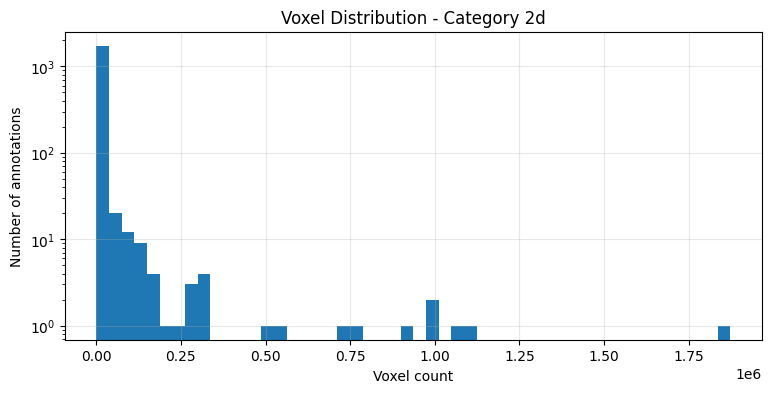

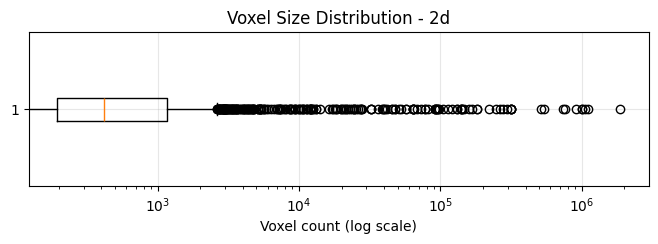


Category: 2c
Number of annotations : 1543
Total voxels          : 175,703,165
Mean voxels           : 113,871.14
Median voxels         : 19,682.00
Minimum voxels        : 0
Maximum voxels        : 3,442,007

Percentiles:
P5: 460
P25: 4,818
P50: 19,682
P75: 83,380
P90: 301,165
P95: 560,393
P99: 1,414,945


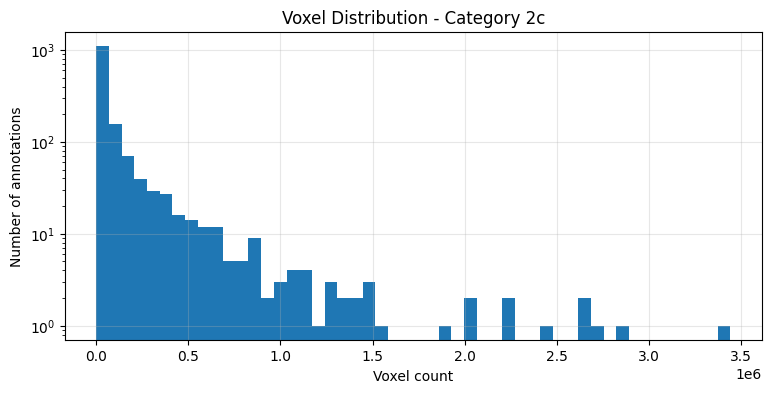

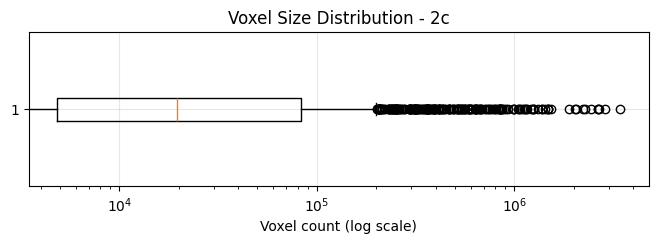

In [11]:
# ============================================================
# Analyze category 2D and 2C separately
# ============================================================

for target_category in ["2d", "2c"]:

    print("\n" + "="*60)
    print(f"Category: {target_category}")
    print("="*60)


    cat_df = df[df["category"].str.lower() == target_category]


    print(f"Number of annotations : {len(cat_df)}")
    print(f"Total voxels          : {cat_df['voxels'].sum():,}")
    print(f"Mean voxels           : {cat_df['voxels'].mean():,.2f}")
    print(f"Median voxels         : {cat_df['voxels'].median():,.2f}")
    print(f"Minimum voxels        : {cat_df['voxels'].min():,}")
    print(f"Maximum voxels        : {cat_df['voxels'].max():,}")


    print("\nPercentiles:")
    for p in [5, 25, 50, 75, 90, 95, 99]:
        print(
            f"P{p}: {np.percentile(cat_df['voxels'], p):,.0f}"
        )


    # ----------------------------
    # Histogram
    # ----------------------------

    plt.figure(figsize=(9,4))

    plt.hist(
        cat_df["voxels"],
        bins=50
    )

    plt.xlabel("Voxel count")
    plt.ylabel("Number of annotations")

    plt.title(
        f"Voxel Distribution - Category {target_category}"
    )

    plt.yscale("log")

    plt.grid(alpha=0.3)

    plt.show()


    # ----------------------------
    # Boxplot
    # ----------------------------

    plt.figure(figsize=(8,2))

    plt.boxplot(
        cat_df["voxels"],
        vert=False
    )

    plt.xscale("log")

    plt.xlabel("Voxel count (log scale)")

    plt.title(
        f"Voxel Size Distribution - {target_category}"
    )

    plt.grid(alpha=0.3)

    plt.show()

Available categories:
category
2d    1801
2c    1543
2b    1403
2a    1169
1c     463
1e     321
1b     286
2e     244
1a     237
1d     200
1f     153
2h      58
2g      19
2f      16
Name: count, dtype: int64

ANALYSIS FOR CATEGORY: 2C

Annotation statistics
Number of annotations: 1543
Number of unique scans: 1161
Total entities: 3360
Total voxels: 175,703,165

Voxel statistics
Mean voxels:   113,871.14
Median voxels: 19,682.00
Min voxels:    0
Max voxels:    3,442,007

Percentiles
P1: 0
P5: 460
P10: 1,336
P25: 4,818
P50: 19,682
P75: 83,380
P90: 301,165
P95: 560,393
P99: 1,414,945

Largest annotations


,scan,finding,voxels,entities
3244,train_5668_a_2.nii.gz,Ground glass opacities in a crazy paving patte...,3442007,2
380,train_2333_a_2.nii.gz,Widespread ground-glass opacities in both lung...,2870098,3
4650,train_10061_a_2.nii.gz,Central and peripheral ground-glass opacities ...,2684768,2
3186,train_6310_a_2.nii.gz,Ground glass opacities predominantly located i...,2642274,1
3185,train_6310_a_2.nii.gz,Ground glass opacities in both lungs without b...,2642274,1
1941,train_6345_a_2.nii.gz,Patchy ground glass opacities in both lungs,2447035,2
134,train_1562_b_2.nii.gz,"Ground-glass opacities in both lungs, more pro...",2266230,3
198,train_1374_a_2.nii.gz,Ground-glass opacities in the lower lobes and ...,2224261,3
2708,train_5803_a_2.nii.gz,Areas of alveolar infiltrates with ground glas...,2051160,2
4079,train_7997_a_2.nii.gz,Widespread ground-glass opacities in both lung...,2024985,1


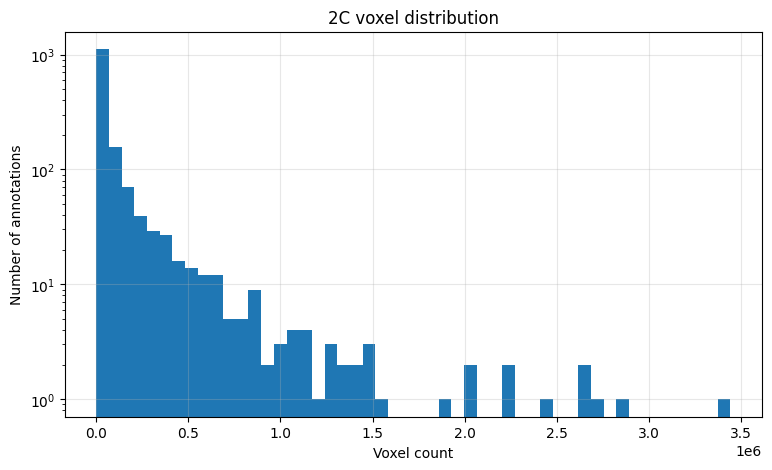

<Figure size 900x500 with 0 Axes>

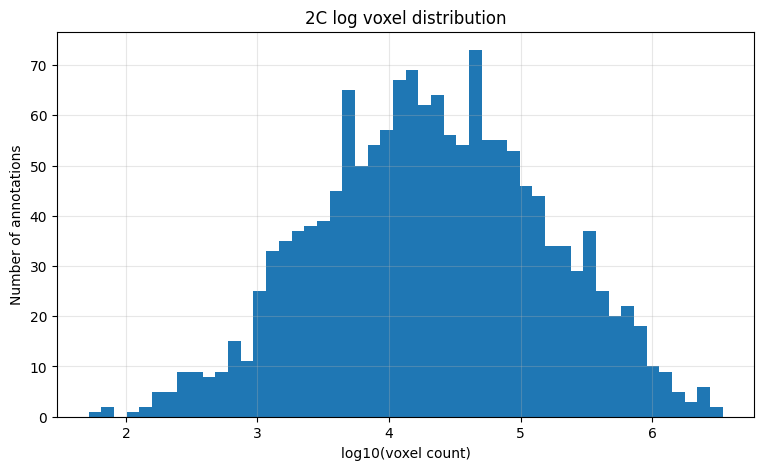

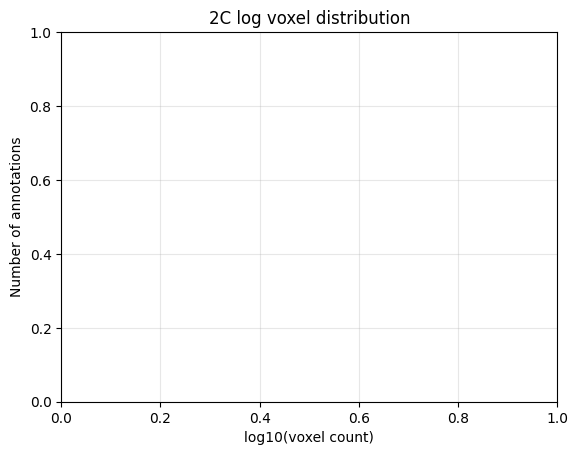

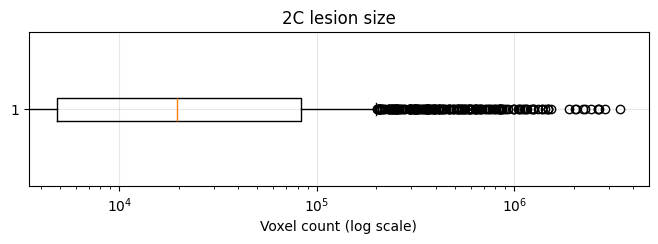


ANALYSIS FOR CATEGORY: 2D

Annotation statistics
Number of annotations: 1801
Number of unique scans: 1349
Total entities: 3185
Total voxels: 18,363,356

Voxel statistics
Mean voxels:   10,196.20
Median voxels: 417.00
Min voxels:    0
Max voxels:    1,872,872

Percentiles
P1: 0
P5: 51
P10: 95
P25: 194
P50: 417
P75: 1,167
P90: 3,387
P95: 17,171
P99: 219,161

Largest annotations


,scan,finding,voxels,entities
5861,valid_123_a_2.nii.gz,Central air bronchograms in both hilar regions...,1872872,2
5571,train_122_b_1.nii.gz,Stable mass in the upper lobe of the right lung,1098312,1
5706,train_186_a_2.nii.gz,Poorly demarcated mass from the pulmonary conu...,1053717,1
5882,train_340_a_1.nii.gz,Mass in the left upper lobe and lingular segme...,994870,1
5883,train_340_a_1.nii.gz,Mass indistinct from adjacent mediastinal stru...,994870,1
5777,train_122_a_1.nii.gz,Mass in the right upper lobe's posterior segme...,911000,1
7299,valid_1016_f_1.nii.gz,Irregularly bordered mass in the medial aspect...,759213,1
5757,train_122_c_1.nii.gz,Unchanged mass with necrotic content in the up...,729636,1
7469,train_1213_a_2.nii.gz,Primary mass in the lower lobe of the right lu...,543818,2
1179,train_1448_c_2.nii.gz,Thick-walled lesion in the right upper lobe,513494,1


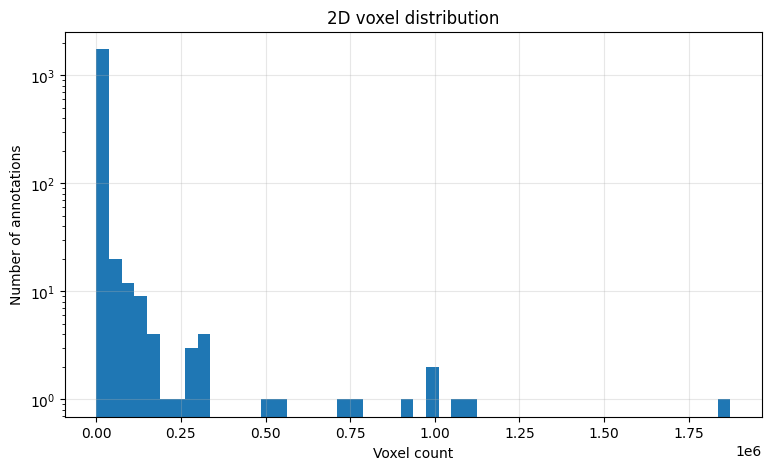

<Figure size 900x500 with 0 Axes>

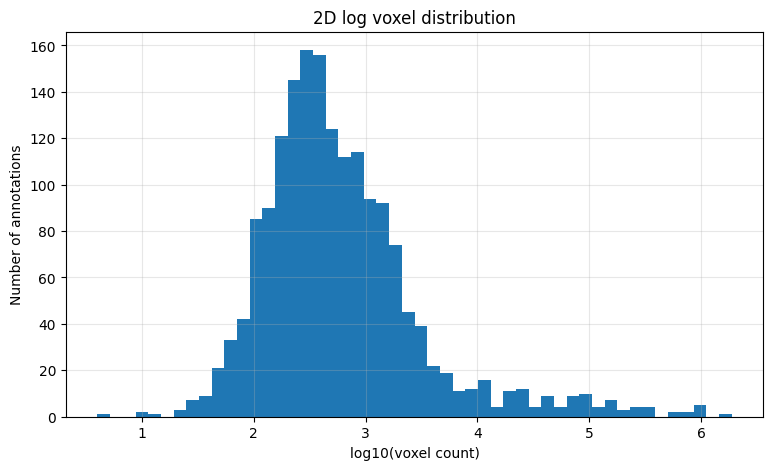

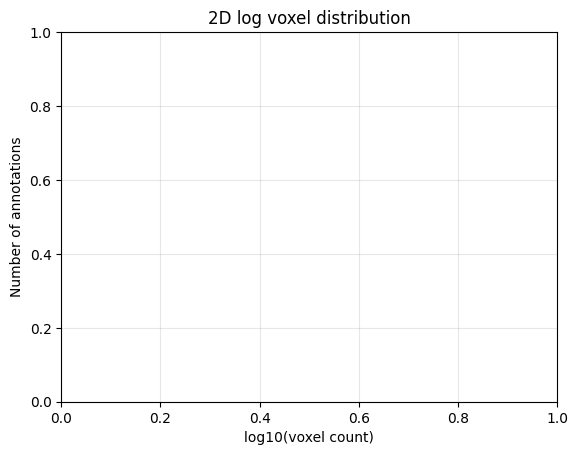

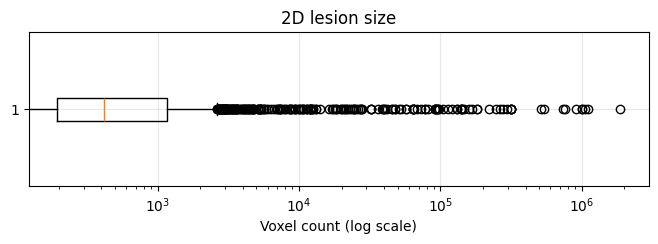

In [12]:
# ============================================================
# Clean category values
# ============================================================

df["category"] = (
    df["category"]
    .astype(str)
    .str.strip()
    .str.lower()
)


# Check available categories
print("Available categories:")
print(df["category"].value_counts())


# ============================================================
# Analyze 2c and 2d separately
# ============================================================

for target_category in ["2c", "2d"]:

    print("\n" + "="*70)
    print(f"ANALYSIS FOR CATEGORY: {target_category.upper()}")
    print("="*70)


    cat_df = df[
        df["category"] == target_category
    ].copy()


    if len(cat_df) == 0:
        print("No annotations found")
        continue


    # --------------------------------------------------------
    # Basic annotation statistics
    # --------------------------------------------------------

    print("\nAnnotation statistics")

    print(
        "Number of annotations:",
        len(cat_df)
    )

    print(
        "Number of unique scans:",
        cat_df["scan"].nunique()
    )

    print(
        "Total entities:",
        cat_df["entities"].sum()
    )

    print(
        "Total voxels:",
        f"{cat_df['voxels'].sum():,}"
    )


    # --------------------------------------------------------
    # Voxel statistics
    # --------------------------------------------------------

    print("\nVoxel statistics")

    print(
        f"Mean voxels:   {cat_df['voxels'].mean():,.2f}"
    )

    print(
        f"Median voxels: {cat_df['voxels'].median():,.2f}"
    )

    print(
        f"Min voxels:    {cat_df['voxels'].min():,}"
    )

    print(
        f"Max voxels:    {cat_df['voxels'].max():,}"
    )


    print("\nPercentiles")

    for p in [1,5,10,25,50,75,90,95,99]:

        print(
            f"P{p}: {np.percentile(cat_df['voxels'],p):,.0f}"
        )


    # --------------------------------------------------------
    # Top largest annotations
    # --------------------------------------------------------

    print("\nLargest annotations")

    display(
        cat_df.sort_values(
            "voxels",
            ascending=False
        )
        .head(10)
        [
            [
                "scan",
                "finding",
                "voxels",
                "entities"
            ]
        ]
    )


    # ========================================================
    # Histogram
    # ========================================================

    plt.figure(figsize=(9,5))

    plt.hist(
        cat_df["voxels"],
        bins=50
    )

    plt.xlabel(
        "Voxel count"
    )

    plt.ylabel(
        "Number of annotations"
    )

    plt.title(
        f"{target_category.upper()} voxel distribution"
    )

    plt.yscale("log")

    plt.grid(alpha=0.3)

    plt.show()



    # ========================================================
    # Log voxel histogram
    # Better for medical lesion sizes
    # ========================================================

    plt.figure(figsize=(9,5))


    # Remove zero voxel annotations before log transform
    positive_voxels = cat_df.loc[
        cat_df["voxels"] > 0,
        "voxels"
    ]


    plt.figure(figsize=(9,5))


    plt.hist(
        np.log10(positive_voxels),
        bins=50
    )


    plt.xlabel(
        "log10(voxel count)"
    )

    plt.ylabel(
        "Number of annotations"
    )


    plt.title(
        f"{target_category.upper()} log voxel distribution"
    )


    plt.grid(alpha=0.3)

    plt.show()


    plt.xlabel(
        "log10(voxel count)"
    )

    plt.ylabel(
        "Number of annotations"
    )


    plt.title(
        f"{target_category.upper()} log voxel distribution"
    )


    plt.grid(alpha=0.3)

    plt.show()



    # ========================================================
    # Boxplot
    # ========================================================

    plt.figure(figsize=(8,2))


    plt.boxplot(
        cat_df["voxels"],
        vert=False
    )


    plt.xscale("log")


    plt.xlabel(
        "Voxel count (log scale)"
    )


    plt.title(
        f"{target_category.upper()} lesion size"
    )


    plt.grid(alpha=0.3)

    plt.show()

   split                   name category  gt_voxels
0  train  train_1741_c_2.nii.gz       2d   120221.0
1  train  train_2282_a_2.nii.gz       2d     6258.0
2  train  train_1694_a_2.nii.gz       2d      846.0
3  train  train_1696_a_2.nii.gz       2d      436.0
4  train  train_1568_a_2.nii.gz       2d     6433.0

Cases:
split  category
test   2c           20
       2d           48
train  2c           55
       2d          365
dtype: int64

Missing GT files:
16

TRAIN - 2c
Cases: 54
Total GT voxels: 5368865
Mean: 99423.42592592593
Median: 6772.0
Std: 199127.98349166467
Min: 140.0
Max: 1098312.0

Percentiles:
0.01       141.06
0.05       375.60
0.25      1608.50
0.50      6772.00
0.75    112880.00
0.95    538657.00
0.99    825924.86
Name: gt_voxels, dtype: float64

TRAIN - 2d
Cases: 350
Total GT voxels: 45144002
Mean: 128982.86285714286
Median: 3457.5
Std: 681608.37170041
Min: 31.0
Max: 8786708.0

Percentiles:
0.01         46.25
0.05        132.90
0.25        636.00
0.50       3457.50
0.75

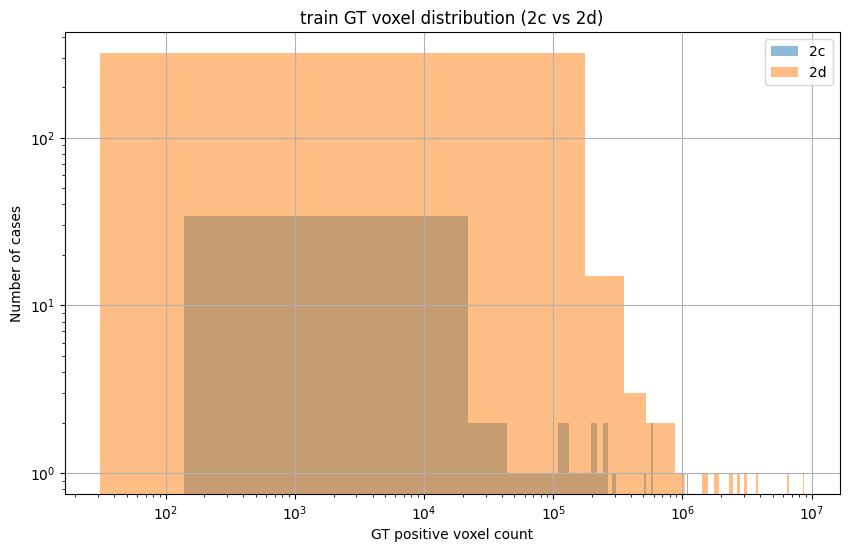

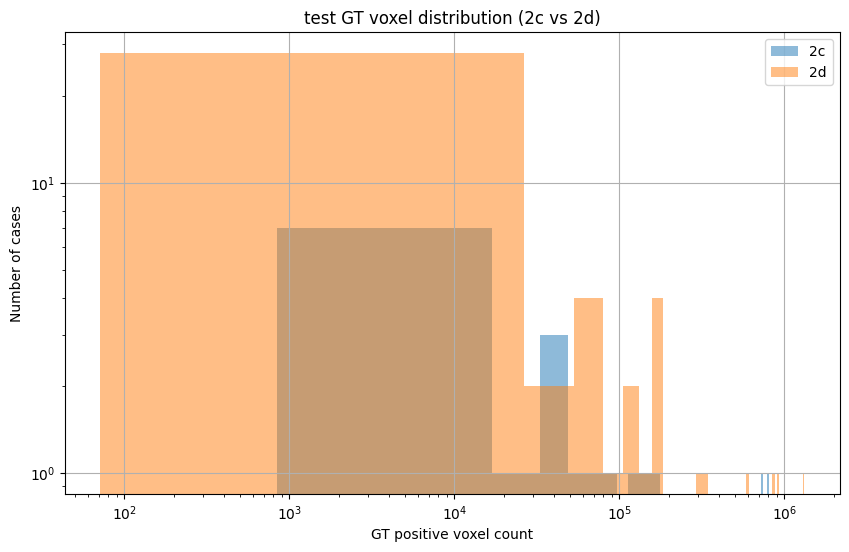

In [13]:
import json
import os
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================

json_path = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2_last.json"

gt_dir = "/home/chest_ct/code/data/segmentations/segmentations"



# ============================================================
# Load JSON
# ============================================================

with open(json_path, "r") as f:
    dataset = json.load(f)



# ============================================================
# Function to count GT voxels
# ============================================================

def get_gt_voxel_count(mask_path):

    if not os.path.exists(mask_path):
        return None


    mask = nib.load(mask_path).get_fdata()


    # If finding dimension exists
    if mask.ndim == 4:
        mask = mask[0]


    return np.count_nonzero(mask > 0)



# ============================================================
# Extract only 2c and 2d cases
# ============================================================

records = []


for split in ["train", "test"]:

    for case in dataset[split]:

        category = case.get("categories", {}).get("1")


        # Ignore normal / empty
        if category not in ["2c", "2d"]:
            continue


        name = case["name"]


        mask_path = os.path.join(
            gt_dir,
            name
        )


        voxel_count = get_gt_voxel_count(
            mask_path
        )


        records.append(
            {
                "split": split,
                "name": name,
                "category": category,
                "gt_voxels": voxel_count
            }
        )



# ============================================================
# Dataframe
# ============================================================

df = pd.DataFrame(records)


print(df.head())


print("\nCases:")
print(
    df.groupby(
        ["split","category"]
    ).size()
)



print("\nMissing GT files:")
print(
    df["gt_voxels"].isna().sum()
)


df = df.dropna()



# ============================================================
# Overall statistics
# ============================================================

for split in ["train","test"]:

    for category in ["2c","2d"]:

        values = df[
            (df["split"] == split) &
            (df["category"] == category)
        ]["gt_voxels"]


        if len(values)==0:
            continue


        print("\n================================")
        print(
            f"{split.upper()} - {category}"
        )
        print("================================")


        print(
            "Cases:",
            len(values)
        )

        print(
            "Total GT voxels:",
            int(values.sum())
        )

        print(
            "Mean:",
            values.mean()
        )

        print(
            "Median:",
            values.median()
        )

        print(
            "Std:",
            values.std()
        )

        print(
            "Min:",
            values.min()
        )

        print(
            "Max:",
            values.max()
        )


        print("\nPercentiles:")

        print(
            values.quantile(
                [
                    0.01,
                    0.05,
                    0.25,
                    0.50,
                    0.75,
                    0.95,
                    0.99
                ]
            )
        )



# ============================================================
# Save results
# ============================================================

df.to_csv(
    "gt_voxel_distribution_2c_2d.csv",
    index=False
)


print(
    "\nSaved gt_voxel_distribution_2c_2d.csv"
)



# ============================================================
# Histograms
# ============================================================

for split in ["train","test"]:

    plt.figure(figsize=(10,6))


    for category in ["2c","2d"]:

        values = df[
            (df["split"] == split) &
            (df["category"] == category)
        ]["gt_voxels"]


        if len(values):

            plt.hist(
                values,
                bins=50,
                alpha=0.5,
                label=category
            )


    plt.xlabel(
        "GT positive voxel count"
    )

    plt.ylabel(
        "Number of cases"
    )

    plt.title(
        f"{split} GT voxel distribution (2c vs 2d)"
    )


    # Lesion sizes vary widely
    plt.xscale("log")
    plt.yscale("log")


    plt.legend()
    plt.grid(True)

    plt.show()

In [14]:
import json
from collections import Counter

# Dataset path
dataset_path = r"/home/chest_ct/code/data/rexgrounding-ct/dataset_2.json"

# Load dataset
with open(dataset_path, "r", encoding="utf-8") as f:
    dataset = json.load(f)

splits = ["train", "val", "test"]

only_2c_cases = []
entity_counter = Counter()

for split in splits:
    for case in dataset.get(split, []):
        categories = case.get("categories", {})

        # Skip scans without annotations
        if len(categories) == 0:
            continue

        unique_categories = set(categories.values())

        # Keep only scans whose abnormalities are exclusively 2c
        if unique_categories == {"2c"}:
            only_2c_cases.append({
                "split": split,
                "name": case["name"],
                "num_findings": len(categories),
                "findings": case["findings"]
            })

            # Count individual abnormalities
            for finding in case["findings"].values():
                entity_counter[finding] += 1

print("=" * 60)
print(f"Cases containing ONLY category 2c: {len(only_2c_cases)}")
print("=" * 60)

print("\nBreakdown of 2c abnormalities:")
for finding, count in entity_counter.most_common():
    print(f"{count:4d} : {finding}")

print("\nFirst 10 matching cases:")
for case in only_2c_cases[:10]:
    print(f"{case['split']:5s}  {case['name']}  ({case['num_findings']} findings)")

Cases containing ONLY category 2c: 938

Breakdown of 2c abnormalities:
  11 : Ground-glass opacities in both lungs
   7 : Ground glass opacities in both lungs
   7 : Patchy ground glass opacities in both lungs
   6 : Patchy ground-glass opacities in both lungs
   6 : Patchy, peripheral-subpleural ground glass opacities in both lungs
   6 : Diffuse ground-glass opacities in both lungs
   5 : Diffuse ground glass opacities in both lungs
   5 : Ground-glass opacities in the lower lobes of both lungs
   4 : Nodular ground-glass opacities in the middle lobe of the right lung
   4 : Mosaic attenuation pattern in both lungs
   4 : Widespread patchy ground-glass opacities in both lungs
   4 : Peripheral and centrally located ground-glass opacities in the upper and lower lobes of both lungs
   4 : Ground-glass opacities in the middle lobe of the right lung
   3 : Round ground glass opacities in both lungs
   3 : Ground-glass opacities in both lungs, more prominently in the lower lobes and perip

In [16]:
import json
from pathlib import Path

path = Path(r"/home/chest_ct/code/data/rexgrounding-ct/dataset_2.json")

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)

matching_cases = []
ground_glass_cases = []

for split_name, split_cases in data.items():
    if not isinstance(split_cases, list):
        continue

    for case in split_cases:
        categories = list(case.get("categories", {}).values())
        if not categories or set(categories) != {"2c"}:
            continue

        findings_text = " ".join(case.get("findings", {}).values()).lower()
        matching_cases.append(case)

        if "ground" in findings_text and "glass" in findings_text:
            ground_glass_cases.append(case)

print("Cases with only 2c as abnormality:", len(matching_cases))
print("Of those, cases containing both 'ground' and 'glass' in findings:", len(ground_glass_cases))

print("\nExamples:")
for case in ground_glass_cases[:20]:
    print(case.get("name"))

Cases with only 2c as abnormality: 938
Of those, cases containing both 'ground' and 'glass' in findings: 913

Examples:
train_2239_a_2.nii.gz
train_1785_a_2.nii.gz
train_1676_a_2.nii.gz
train_1753_e_2.nii.gz
train_2256_a_2.nii.gz
train_2226_a_1.nii.gz
train_1296_a_2.nii.gz
train_1349_a_2.nii.gz
train_2234_a_1.nii.gz
train_1312_a_2.nii.gz
train_2329_f_1.nii.gz
train_1562_b_2.nii.gz
train_1850_a_1.nii.gz
train_1823_a_2.nii.gz
train_2347_a_1.nii.gz
train_1534_a_2.nii.gz
train_1823_b_2.nii.gz
train_1822_b_2.nii.gz
train_1950_a_2.nii.gz
train_1942_a_1.nii.gz


In [17]:
import json
from pathlib import Path

path = Path(r"/home/chest_ct/code/data/rexgrounding-ct/dataset_2.json")

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)

matching_cases = []
nodule_cases = []

for split_name, split_cases in data.items():
    if not isinstance(split_cases, list):
        continue

    for case in split_cases:
        categories = list(case.get("categories", {}).values())
        if not categories or set(categories) != {"2c"}:
            continue

        findings_text = " ".join(case.get("findings", {}).values()).lower()
        matching_cases.append(case)

        if "nodule" in findings_text or "nodular" in findings_text:
            nodule_cases.append(case)

print("Cases with only 2c as abnormality:", len(matching_cases))
print("Of those, cases containing 'nodule' or 'nodular' in findings:", len(nodule_cases))

print("\nExamples:")
for case in nodule_cases[:20]:
    print(case.get("name"))

Cases with only 2c as abnormality: 938
Of those, cases containing 'nodule' or 'nodular' in findings: 150

Examples:
train_1676_a_2.nii.gz
train_2226_a_1.nii.gz
train_1850_a_1.nii.gz
train_1823_a_2.nii.gz
train_1822_b_2.nii.gz
train_1353_a_2.nii.gz
train_1313_a_2.nii.gz
train_1324_a_2.nii.gz
train_2075_b_1.nii.gz
train_2126_a_1.nii.gz
train_2254_a_2.nii.gz
train_1395_a_1.nii.gz
train_2003_a_2.nii.gz
train_1742_d_2.nii.gz
train_2056_a_2.nii.gz
train_1589_a_2.nii.gz
train_1717_b_1.nii.gz
train_1651_a_1.nii.gz
train_1493_a_1.nii.gz
train_1906_a_1.nii.gz


In [20]:
import json
from pathlib import Path

path = Path(r"/home/chest_ct/code/data/rexgrounding-ct/dataset_2.json")

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)

matching_cases = []
nodule_cases = []

for split_name, split_cases in data.items():
    if not isinstance(split_cases, list):
        continue

    for case in split_cases:
        categories = list(case.get("categories", {}).values())
        if not categories or set(categories) != {"2c"}:
            continue

        findings_text = " ".join(case.get("findings", {}).values()).lower()
        matching_cases.append(case)

        if "consolidation" in findings_text:
            nodule_cases.append(case)

print("Cases with only 2c as abnormality:", len(matching_cases))
print("Of those, cases containing 'consolidation' in findings:", len(nodule_cases))

print("\nExamples:")
for case in nodule_cases[:20]:
    print(case.get("name"))

Cases with only 2c as abnormality: 938
Of those, cases containing 'consolidation' in findings: 27

Examples:
train_1942_a_1.nii.gz
train_1313_a_2.nii.gz
train_2043_a_2.nii.gz
train_2126_a_1.nii.gz
train_1837_a_2.nii.gz
train_1422_c_2.nii.gz
train_6158_b_1.nii.gz
train_8078_a_1.nii.gz
train_6464_a_2.nii.gz
train_10987_a_1.nii.gz
train_12312_b_1.nii.gz
train_11619_a_1.nii.gz
train_11491_a_1.nii.gz
train_12840_a_2.nii.gz
train_12165_a_1.nii.gz
train_11995_a_2.nii.gz
train_11184_c_1.nii.gz
train_13890_a_2.nii.gz
train_60_d_1.nii.gz
train_107_c_2.nii.gz


In [21]:
import json
from pathlib import Path


matching_cases = []
nodule_cases = []

for split_name, split_cases in data.items():
    if not isinstance(split_cases, list):
        continue

    for case in split_cases:
        categories = list(case.get("categories", {}).values())
        if not categories or set(categories) != {"2c"}:
            continue

        findings_text = " ".join(case.get("findings", {}).values()).lower()
        matching_cases.append(case)

        if "mosaic" in findings_text:
            nodule_cases.append(case)

print("Cases with only 2c as abnormality:", len(matching_cases))
print("Of those, cases containing 'mosaic' in findings:", len(nodule_cases))

print("\nExamples:")
for case in nodule_cases[:20]:
    print(case.get("name"))

Cases with only 2c as abnormality: 938
Of those, cases containing 'mosaic' in findings: 9

Examples:
train_2316_a_1.nii.gz
train_2083_a_2.nii.gz
train_6021_a_2.nii.gz
train_7087_a_1.nii.gz
train_12794_c_2.nii.gz
train_13355_c_2.nii.gz
valid_314_a_2.nii.gz
valid_597_a_1.nii.gz
valid_919_a_2.nii.gz


In [22]:
import json
from pathlib import Path



remove_cases = []
keep_cases = []


for split_name, split_cases in data.items():

    if not isinstance(split_cases, list):
        continue

    for case in split_cases:

        categories = list(case.get("categories", {}).values())

        # only 2c cases
        if not categories or set(categories) != {"2c"}:
            continue


        findings_text = " ".join(
            case.get("findings", {}).values()
        ).lower()


        has_ggo = (
            "ground glass" in findings_text 
            or "ground-glass" in findings_text
        )

        has_nodule = (
            "nodule" in findings_text
            or "nodular" in findings_text
        )

        has_consolidation = (
            "consolidation" in findings_text
        )

        has_mosaic = (
            "mosaic" in findings_text
        )


        # Keep only clean GGO cases
        if (
            has_ggo
            and not has_nodule
            and not has_consolidation
            and not has_mosaic
        ):
            keep_cases.append(case["name"])

        else:
            remove_cases.append(case["name"])


print("Total 2c-only cases:", len(remove_cases) + len(keep_cases))
print("Kept pure GGO cases:", len(keep_cases))
print("Removed cases:", len(remove_cases))


print("\nRemoved examples:")
for c in remove_cases[:20]:
    print(c)

Total 2c-only cases: 938
Kept pure GGO cases: 743
Removed cases: 195

Removed examples:
train_1676_a_2.nii.gz
train_2226_a_1.nii.gz
train_1850_a_1.nii.gz
train_1823_a_2.nii.gz
train_1822_b_2.nii.gz
train_1942_a_1.nii.gz
train_1353_a_2.nii.gz
train_1313_a_2.nii.gz
train_1324_a_2.nii.gz
train_2075_b_1.nii.gz
train_2043_a_2.nii.gz
train_2126_a_1.nii.gz
train_1593_b_2.nii.gz
train_2254_a_2.nii.gz
train_1395_a_1.nii.gz
train_1837_a_2.nii.gz
train_2003_a_2.nii.gz
train_1742_d_2.nii.gz
train_2056_a_2.nii.gz
train_1589_a_2.nii.gz


# EDA for all JSONs

In [26]:
import json
from pathlib import Path
from collections import Counter

dataset_paths = [
    Path(r"/home/chest_ct/code/data/rexgrounding-ct/dataset_2.json"),
    Path(r"/home/chest_ct/code/data/rexgrounding-ct/dataset_2_cleaned.json"),
    Path(r"/home/chest_ct/code/data/rexgrounding-ct/dataset_2_last.json"),
]


def count_categories(dataset_path):
    with dataset_path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    split_counters = {}

    for split_name, split_cases in data.items():

        if not isinstance(split_cases, list):
            continue

        counter = Counter()

        for case in split_cases:
            categories = list(case.get("categories", {}).values())

            if not categories:
                counter["empty"] += 1
            else:
                key = ", ".join(sorted(set(categories)))
                counter[key] += 1

        split_counters[split_name] = counter

    return split_counters


for dataset_path in dataset_paths:

    split_counters = count_categories(dataset_path)

    print("\n" + "=" * 60)
    print(dataset_path.name)
    print("=" * 60)

    for split_name, counter in split_counters.items():

        print(f"\n--- {split_name} ---")
        print("CT cases by category combination\n")

        for category, count in sorted(counter.items()):
            print(f"{category:40s} : {count}")


        print(f"Total {split_name}: {sum(counter.values())}")


dataset_2.json

--- train ---
CT cases by category combination

2c                                       : 708
2c, 2d                                   : 175
2d                                       : 849
empty                                    : 347
Total train: 2079

--- test ---
CT cases by category combination

2c                                       : 230
2c, 2d                                   : 63
2d                                       : 290
Total test: 583

dataset_2_cleaned.json

--- train ---
CT cases by category combination

2c                                       : 565
2c, 2d                                   : 175
2d                                       : 849
empty                                    : 347
Total train: 1936

--- test ---
CT cases by category combination

2c                                       : 178
2c, 2d                                   : 63
2d                                       : 290
Total test: 531

dataset_2_last.json

--- train ---
CT cas

In [27]:
import json
from pathlib import Path
from collections import Counter

dataset_path = Path(
    r"/home/chest_ct/code/data/rexgrounding-ct/dataset_2_last.json"
)

with dataset_path.open("r", encoding="utf-8") as f:
    data = json.load(f)


def find_duplicates(names):
    counter = Counter(names)
    return {k: v for k, v in counter.items() if v > 1}


train_names = [case["name"] for case in data["train"]]
test_names = [case["name"] for case in data["test"]]

train_set = set(train_names)
test_set = set(test_names)

train_dups = find_duplicates(train_names)
test_dups = find_duplicates(test_names)

cross_dups = sorted(train_set & test_set)

all_names = train_names + test_names
all_dups = find_duplicates(all_names)

train_normal = sum(
    case.get("categories", {}) == {}
    for case in data["train"]
)

test_normal = sum(
    case.get("categories", {}) == {}
    for case in data["test"]
)

print("=" * 60)
print("Dataset validation")
print("=" * 60)

print(f"Train cases          : {len(train_names)}")
print(f"Test cases           : {len(test_names)}")
print(f"Total cases          : {len(all_names)}")
print(f"Unique case names    : {len(set(all_names))}")

print("\nNormal cases")
print(f"  Train : {train_normal}")
print(f"  Test  : {test_normal}")

print("\nDuplicate names within train :", len(train_dups))
if train_dups:
    print(list(train_dups.items())[:20])

print("\nDuplicate names within test :", len(test_dups))
if test_dups:
    print(list(test_dups.items())[:20])

print("\nCases present in BOTH train and test :", len(cross_dups))
if cross_dups:
    print(cross_dups[:20])

print("\nDuplicate names anywhere in dataset :", len(all_dups))
if all_dups:
    print(list(all_dups.items())[:20])

Dataset validation
Train cases          : 1314
Test cases           : 184
Total cases          : 1498
Unique case names    : 1498

Normal cases
  Train : 100
  Test  : 21

Duplicate names within train : 0

Duplicate names within test : 0

Cases present in BOTH train and test : 0

Duplicate names anywhere in dataset : 0


# Patch-level metrics

In [2]:
import pandas as pd

# =============================================================================
# Load patch-level results
# =============================================================================
csv_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/results/lcksvd2_svm_test_20260731_145717/patch_level.csv"

df = pd.read_csv(csv_path)

print(f"Total patches : {len(df):,}")
print(f"Total scans   : {df['scan_id'].nunique():,}")

# =============================================================================
# Compute scan-level statistics
# =============================================================================
scan_stats = (
    df.groupby("scan_id")
      .agg(
          total_patches=("correct", "count"),
          correct_patches=("correct", "sum"),
          true_label=("true_label", "first")
      )
      .reset_index()
)

scan_stats["incorrect_patches"] = (
    scan_stats["total_patches"] - scan_stats["correct_patches"]
)

scan_stats["accuracy"] = (
    scan_stats["correct_patches"] / scan_stats["total_patches"]
)

# =============================================================================
# Best scans
# =============================================================================
best_scans = (
    scan_stats
    .sort_values(
        ["accuracy", "correct_patches", "total_patches"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

# =============================================================================
# Worst scans
# =============================================================================
worst_scans = (
    scan_stats
    .sort_values(
        ["accuracy", "incorrect_patches", "total_patches"],
        ascending=[True, False, False]
    )
    .reset_index(drop=True)
)

# =============================================================================
# Display
# =============================================================================
print("\n================== TOP 20 BEST SCANS ==================\n")
display(best_scans.head(50))

print("\n================== TOP 20 WORST SCANS ==================\n")
display(worst_scans.head(20))

# =============================================================================
# Save
# =============================================================================
out_best = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/results/best_scans.csv"
out_worst = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/results/worst_scans.csv"

best_scans.to_csv(out_best, index=False)
worst_scans.to_csv(out_worst, index=False)

print(f"\nSaved best scans  -> {out_best}")
print(f"Saved worst scans -> {out_worst}")

# =============================================================================
# Summary
# =============================================================================
print("\nAccuracy statistics")
print(scan_stats["accuracy"].describe())

print("\nPerfectly classified scans :", (scan_stats["accuracy"] == 1.0).sum())
print("Completely wrong scans     :", (scan_stats["accuracy"] == 0.0).sum())

,scan_id,total_patches,correct_patches,true_label,incorrect_patches,accuracy
0,valid_457_d_2,6,6,2,0,1.000000
1,valid_466_a_2,3,3,1,0,1.000000
2,train_18107_a_2,858,805,0,53,0.938228
3,train_17370_a_1,762,711,0,51,0.933071
4,train_6321_b_2,1029,948,0,81,0.921283
5,valid_902_a_2,1113,1016,2,97,0.912848
6,train_5864_b_1,609,552,0,57,0.906404
7,train_15829_a_1,392,354,0,38,0.903061
8,valid_102_a_2,154,139,2,15,0.902597
9,train_8143_a_1,587,529,0,58,0.901193



================== TOP 20 WORST SCANS ==================



,scan_id,total_patches,correct_patches,true_label,incorrect_patches,accuracy
0,valid_573_a_1,2,0,2,2,0.000000
1,train_81_a_2,1,0,1,1,0.000000
2,train_844_a_2,1,0,1,1,0.000000
3,valid_1103_a_2,22,1,2,21,0.045455
4,valid_459_a_2,241,15,1,226,0.062241
5,train_277_a_1,16,1,1,15,0.062500
6,train_623_a_2,2231,147,1,2084,0.065890
7,train_894_a_1,15,1,1,14,0.066667
8,valid_937_a_2,401,27,1,374,0.067332
9,train_863_b_2,133,9,1,124,0.067669



Saved best scans  -> /home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/results/best_scans.csv
Saved worst scans -> /home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/results/worst_scans.csv

Accuracy statistics
count    89.000000
mean      0.513542
std       0.314751
min       0.000000
25%       0.261561
50%       0.490566
75%       0.838120
max       1.000000
Name: accuracy, dtype: float64

Perfectly classified scans : 2
Completely wrong scans     : 3


In [8]:
# =============================================================================
# Per-case (per-scan) accuracy on abnormal patches only (true_label 1="2c", 2="2d")
# =============================================================================
abnormal_df = df[df["true_label"] != 0]

abnormal_scan_stats = (
    abnormal_df.groupby("scan_id")
    .agg(
        total_abnormal_patches=("correct", "count"),
        correct_abnormal_patches=("correct", "sum"),
        true_label=("true_label", "first"),
        true_class=("true_class", "first"),
    )
    .reset_index()
)

abnormal_scan_stats["incorrect_abnormal_patches"] = (
    abnormal_scan_stats["total_abnormal_patches"] - abnormal_scan_stats["correct_abnormal_patches"]
)

abnormal_scan_stats["abnormal_accuracy"] = (
    abnormal_scan_stats["correct_abnormal_patches"] / abnormal_scan_stats["total_abnormal_patches"]
)

abnormal_scan_stats = abnormal_scan_stats.sort_values("abnormal_accuracy", ascending=False).reset_index(drop=True)

print(f"Total abnormal scans (cases): {abnormal_scan_stats['scan_id'].nunique():,}")
display(abnormal_scan_stats)

# save
out_abnormal = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/results/abnormal_scan_accuracy.csv"
abnormal_scan_stats.to_csv(out_abnormal, index=False)
print(f"\nSaved per-case abnormal accuracy -> {out_abnormal}")

# summary
print("\nPer-case abnormal accuracy statistics")
print(abnormal_scan_stats["abnormal_accuracy"].describe())

print("\nPerfectly classified abnormal cases :", (abnormal_scan_stats["abnormal_accuracy"] == 1.0).sum())
print("Completely wrong abnormal cases     :", (abnormal_scan_stats["abnormal_accuracy"] == 0.0).sum())


Total abnormal scans (cases): 68


,scan_id,total_abnormal_patches,correct_abnormal_patches,true_label,true_class,incorrect_abnormal_patches,abnormal_accuracy
0,valid_466_a_2,3,3,1,2c,0,1.000000
1,valid_457_d_2,6,6,2,2d,0,1.000000
2,valid_902_a_2,1113,1016,2,2d,97,0.912848
3,valid_102_a_2,154,139,2,2d,15,0.902597
4,valid_342_a_2,102,90,1,2c,12,0.882353
...,...,...,...,...,...,...,...
63,valid_459_a_2,241,15,1,2c,226,0.062241
64,valid_1103_a_2,22,1,2,2d,21,0.045455
65,train_844_a_2,1,0,1,2c,1,0.000000
66,train_81_a_2,1,0,1,2c,1,0.000000



Saved per-case abnormal accuracy -> /home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/results/abnormal_scan_accuracy.csv

Per-case abnormal accuracy statistics
count    68.000000
mean      0.402384
std       0.276262
min       0.000000
25%       0.151167
50%       0.376848
75%       0.572905
max       1.000000
Name: abnormal_accuracy, dtype: float64

Perfectly classified abnormal cases : 2
Completely wrong abnormal cases     : 3


In [5]:
import json
from pathlib import Path

# =============================================================================
# Paths
# =============================================================================
INPUT_JSON = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2_last.json"
OUTPUT_JSON = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2_last_filtered.json"

# =============================================================================
# Test scan IDs to keep (without .nii.gz)
# =============================================================================
KEEP_TEST_IDS = {
    "train_81_a_2",
    "valid_1067_a_2",
    "train_122_c_1",
    "valid_102_a_2",
    "train_412_a_2",
    "valid_276_a_2",
    "valid_902_a_2",
    "train_122_a_1",
    "train_18107_a_2",
    "train_119_a_2",
    "train_6321_b_2",
    "train_8143_a_1",
    "train_3994_a_1",
    "train_12132_a_2",
    "valid_342_a_2",
    "train_16003_a_2",
    "train_317_c_2",
    "train_17370_a_1",
    "train_2510_a_1",
    "train_5864_b_1",
    "train_15753_a_2",
    "train_4335_a_2",
    "train_19798_a_2",
    "train_14336_a_2",
    "train_437_a_1",
    "train_17896_b_2",
    "train_16110_a_1",
    "train_24_a_2",
    "valid_123_a_2",
    "valid_660_a_2",
    "train_856_a_2",
    "train_1157_e_2",
    "train_15829_a_1",
    "train_5977_a_2",
    "train_783_a_2",
    "valid_1016_d_1",
    "train_5425_a_2",
    "valid_457_d_2",
    "train_16404_a_1",
    "train_990_a_1",
}

# =============================================================================
# Load dataset
# =============================================================================
with open(INPUT_JSON, "r") as f:
    dataset = json.load(f)

print(f"Original train size : {len(dataset['train'])}")
print(f"Original test size  : {len(dataset['test'])}")

# =============================================================================
# Filter test split
# =============================================================================
new_test = []
found_ids = set()

for sample in dataset["test"]:
    scan_id = Path(sample["name"]).stem

    # Handle .nii.gz correctly
    if scan_id.endswith(".nii"):
        scan_id = scan_id[:-4]

    if scan_id in KEEP_TEST_IDS:
        new_test.append(sample)
        found_ids.add(scan_id)

missing = sorted(KEEP_TEST_IDS - found_ids)

# =============================================================================
# Create new dataset
# =============================================================================
new_dataset = {
    "train": dataset["train"],
    "test": new_test,
}

# =============================================================================
# Save
# =============================================================================
with open(OUTPUT_JSON, "w") as f:
    json.dump(new_dataset, f, indent=4)

# =============================================================================
# Summary
# =============================================================================
print("\n==================== SUMMARY ====================")
print(f"Original test scans : {len(dataset['test'])}")
print(f"Requested scans     : {len(KEEP_TEST_IDS)}")
print(f"Found scans         : {len(found_ids)}")
print(f"Saved test scans    : {len(new_test)}")
print(f"Missing scans       : {len(missing)}")

if missing:
    print("\nMissing scan IDs:")
    for m in missing:
        print(" ", m)

print(f"\nSaved to:\n{OUTPUT_JSON}")

Original train size : 1314
Original test size  : 184

==================== SUMMARY ====================
Original test scans : 184
Requested scans     : 40
Found scans         : 40
Saved test scans    : 40
Missing scans       : 0

Saved to:
/home/chest_ct/code/data/rexgrounding-ct/dataset_2_last_filtered.json


In [1]:
import json
import numpy as np

# Load patch matrix scan ids
patches = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_shuffled.npz",
    allow_pickle=True,
)
patch_scan_ids = set(patches["scan_ids"])  # e.g. "train_122_b_1" (no .nii.gz)

# Load json dataset (train split, since patches file is "unified_train_shuffled")
with open("/home/chest_ct/code/data/rexgrounding-ct/dataset_2_last.json") as f:
    dataset = json.load(f)

json_names = {entry["name"].removesuffix(".nii.gz") for entry in dataset["train"]}

missing_from_patches = sorted(json_names - patch_scan_ids)
extra_in_patches = sorted(patch_scan_ids - json_names)

print(f"JSON train scans: {len(json_names)}")
print(f"Unique scans in patch matrix: {len(patch_scan_ids)}")
print(f"In JSON but missing from patches: {len(missing_from_patches)}")
print(f"In patches but not in JSON: {len(extra_in_patches)}")

missing_from_patches[:20]


JSON train scans: 1314
Unique scans in patch matrix: 239
In JSON but missing from patches: 1075
In patches but not in JSON: 0


['train_10000_a_1',
 'train_10006_b_2',
 'train_10017_a_2',
 'train_10083_a_2',
 'train_10083_b_2',
 'train_10083_c_2',
 'train_1008_a_2',
 'train_10094_a_2',
 'train_10094_c_1',
 'train_10104_a_1',
 'train_10106_a_2',
 'train_1015_a_1',
 'train_10165_a_1',
 'train_10177_a_2',
 'train_10180_a_2',
 'train_1018_a_2',
 'train_10198_a_2',
 'train_10198_b_2',
 'train_10216_a_1',
 'train_10243_a_1']

# New EDA

In [2]:
import json

import pandas as pd

with open("/home/chest_ct/code/data/rexgrounding-ct/dataset.json", "r") as f:
    data = json.load(f)

rows = []

for split, samples in data.items():
    for sample in samples:
        for idx in sample["findings"]:
            rows.append({
                "split": split,
                "name": sample["name"],
                "index": int(idx),
                "findings": sample["findings"][idx],
                "entity_counts": sample["entity_counts"][idx],
                "pixels": sample["pixels"][idx],
                "categories": sample["categories"][idx],
            })

df = pd.DataFrame(rows)

df.head()

,split,name,index,findings,entity_counts,pixels,categories
0,train,train_1741_b_2.nii.gz,0,Irregularly circumscribed nodular consolidatio...,1,15571,2b
1,train,train_1935_a_1.nii.gz,0,Segmental and subsegmental peribronchial thick...,2,101934,1a
2,train,train_1935_a_1.nii.gz,1,Mosaic attenuation pattern in both lungs,3,315619,2c
3,train,train_1935_a_1.nii.gz,2,Reticulonodular density increases in both lung...,2,10405,1d
4,train,train_1935_a_1.nii.gz,3,Paraseptal emphysema in both lung apices,3,7065,1c


In [3]:
scan_counts = (
    df
    .groupby("categories")["name"]
    .nunique()
    .reset_index(name="num_scans")
)

print(scan_counts)

   categories  num_scans
0          1a        213
1          1b        249
2          1c        421
3          1d        188
4          1e        246
5          1f        145
6          2a        815
7          2b        924
8          2c       1144
9          2d       1333
10         2e        186
11         2f         15
12         2g         15
13         2h         58


In [4]:
VALID_CATEGORIES = {"1c", "2b", "2c", "2d"}

# Find scans where all findings are in the allowed categories
valid_scans = (
    df.groupby("name")["categories"]
    .apply(lambda x: set(x).issubset(VALID_CATEGORIES))
)

# Keep only valid scans
valid_scan_names = valid_scans[valid_scans].index

df_shortlisted = df[
    df["name"].isin(valid_scan_names)
].copy()

print("Remaining scans:", df_shortlisted["name"].nunique())
print("Remaining findings:", len(df_shortlisted))
print("\nCategory distribution:")
print(df_shortlisted["categories"].value_counts())
display(df_shortlisted)

Remaining scans: 1539
Remaining findings: 2744

Category distribution:
categories
2d    971
2c    897
2b    703
1c    173
Name: count, dtype: int64


,split,name,index,findings,entity_counts,pixels,categories
0,train,train_1741_b_2.nii.gz,0,Irregularly circumscribed nodular consolidatio...,1,15571,2b
6,train,train_1591_f_2.nii.gz,0,Regression of consolidation areas in the middl...,2,43449,2b
7,train,train_1591_f_2.nii.gz,1,Atelectatic changes in the posterobasal segmen...,1,79203,2b
8,train,train_1591_f_2.nii.gz,2,Fibroatelectatic changes in the anterolateral ...,1,2894,2b
9,train,train_1591_f_2.nii.gz,3,Newly revealed focal acinar infiltration areas...,1,30384,2b
...,...,...,...,...,...,...,...
7797,val,train_13444_a_2.nii.gz,0,One or two nonspecific parenchymal nodules in ...,3,196,2d
7798,val,train_13316_a_2.nii.gz,0,Multiple parenchymal nodules in both lungs,9,946,2d
7799,val,train_13316_a_2.nii.gz,1,Largest nodule in the anterobasal segment of t...,1,3688,2d
7800,val,train_13339_a_1.nii.gz,0,"Nonspecific pulmonary nodule, 3.9 mm, in the a...",1,118,2d


In [5]:
# Select category 2d
df_2d = df_shortlisted[df_shortlisted["categories"] == "2d"].copy()

# Findings with more than 3456 pixels
df_2d_large = df_2d[df_2d["pixels"] > 3456].copy()

# Counts
num_findings = len(df_2d_large)
num_scans = df_2d_large["name"].nunique()

print(f"2d findings with >3456 pixels: {num_findings}")
print(f"2d scans with >3456 pixels: {num_scans}")

display(df_2d_large.head())

2d findings with >3456 pixels: 73
2d scans with >3456 pixels: 51


,split,name,index,findings,entity_counts,pixels,categories
39,train,train_1591_c_2.nii.gz,5,Subcentimeter nonspecific parenchymal nodules ...,3,4746,2d
378,train,train_1387_a_2.nii.gz,0,Multiple metastases in both lungs without any ...,3,7253,2d
459,train,train_1767_a_2.nii.gz,3,Stable nodule adjacent to the consolidation in...,1,12518,2d
466,train,train_1758_b_2.nii.gz,2,New lesion measuring up to 23 mm in the paraca...,1,21584,2d
721,train,train_1758_a_2.nii.gz,0,Multiple focal nodular lesions with spiculated...,3,12219,2d


In [6]:
print("\ndf_shortlisted:")
print(f"  rows  : {len(df_shortlisted)}")
print(f"  scans : {df_shortlisted['name'].nunique()}")

# Get scan IDs that have 2d findings >3456 pixels
large_2d_scans = df_2d_large["name"].unique()

# 1. Move complete scans
df_shortlisted_2d_large = df_shortlisted[
    df_shortlisted["name"].isin(large_2d_scans)
].copy()

# 2. Remove those scans
df_shortlisted = df_shortlisted[
    ~df_shortlisted["name"].isin(large_2d_scans)
].copy()

# 4. Keep only non-2d findings
df_shortlisted_without_2d = df_shortlisted[
    df_shortlisted["categories"] != "2d"
].copy()


# Verify
print("df_shortlisted_2d_large:")
print(f"  rows  : {len(df_shortlisted_2d_large)}")
print(f"  scans : {df_shortlisted_2d_large['name'].nunique()}")

print("\nRemaining df_shortlisted:")
print(f"  rows  : {len(df_shortlisted)}")
print(f"  scans : {df_shortlisted['name'].nunique()}")

print("\ndf_shortlisted_without_2d:")
print(f"  rows  : {len(df_shortlisted_without_2d)}")
print(f"  scans : {df_shortlisted_without_2d['name'].nunique()}")


df_shortlisted:
  rows  : 2744
  scans : 1539
df_shortlisted_2d_large:
  rows  : 164
  scans : 51

Remaining df_shortlisted:
  rows  : 2580
  scans : 1488

df_shortlisted_without_2d:
  rows  : 1704
  scans : 983


In [7]:
# gete scan ids that have finding 1c
scan_ids_1c = df_shortlisted_without_2d[
    df_shortlisted_without_2d["categories"] == "1c"
]["name"].unique()

# move 1c scans to a separate dataframe
df_shortlisted_1c = df_shortlisted_without_2d[
    df_shortlisted_without_2d["name"].isin(scan_ids_1c)
].copy()


# remove those scans from df_shortlisted_without_2d to a new dataframe
df_shortlisted_without_1c = df_shortlisted_without_2d[
    ~df_shortlisted_without_2d["name"].isin(scan_ids_1c)
].copy()

# verify
print("df_shortlisted_1c:")
print(f"  rows  : {len(df_shortlisted_1c)}")
print(f"  scans : {df_shortlisted_1c['name'].nunique()}")

print("\ndf_shortlisted_without_1c:")
print(f"  rows  : {len(df_shortlisted_without_1c)}")
print(f"  scans : {df_shortlisted_without_1c['name'].nunique()}")

df_shortlisted_1c:
  rows  : 265
  scans : 157

df_shortlisted_without_1c:
  rows  : 1439
  scans : 826


            count           mean            std   min      25%      50%  \
categories                                                                
2b          609.0  120557.648604  359560.876490   8.0  6049.00  21139.0   
2c          830.0   99421.386747  248992.881561  69.0  4878.75  18524.0   

                 75%        max  
categories                       
2b          79338.00  5231506.0  
2c          72791.25  2642274.0  


<Figure size 800x600 with 0 Axes>

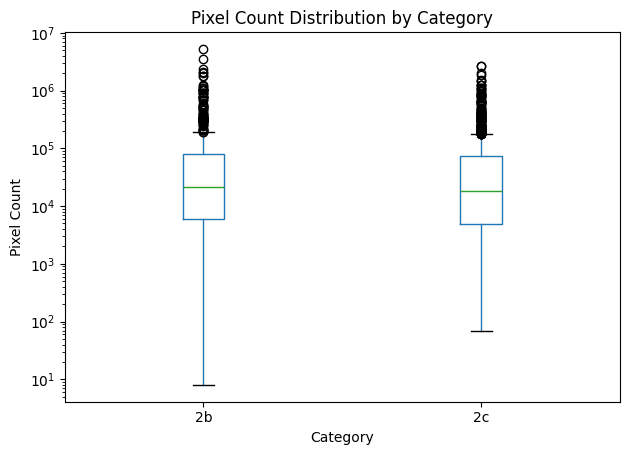

In [8]:
import matplotlib.pyplot as plt

# Ensure pixels are numeric
df_shortlisted_without_1c["pixels"] = pd.to_numeric(df_shortlisted_without_1c["pixels"])

# Plot
plt.figure(figsize=(8, 6))

df_shortlisted_without_1c.boxplot(
    column="pixels",
    by="categories",
    grid=False
)

stats = (
    df_shortlisted_without_1c
    .groupby("categories")["pixels"]
    .describe()
)

print(stats)

plt.title("Pixel Count Distribution by Category")
plt.suptitle("")  # Remove the automatic pandas subtitle
plt.xlabel("Category")
plt.ylabel("Pixel Count")

# Uncomment if the distributions are highly skewed
plt.yscale("log")

plt.tight_layout()
plt.show()

In [9]:
boxes = {}

for category, group in df_shortlisted_without_1c.groupby("categories"):
    q1 = group["pixels"].quantile(0.25)
    q3 = group["pixels"].quantile(0.75)

    boxes[category] = (q1, q3)

# Keep only rows inside the box (Q1 <= pixels <= Q3)
mask = df_shortlisted_without_1c.apply(
    lambda row: boxes[row["categories"]][0]
                <= row["pixels"]
                <= boxes[row["categories"]][1],
    axis=1,
)

df_within_box = df_shortlisted_without_1c[mask].copy()

# Find scans where ALL findings are within their category box
common_scans = (
    df_within_box.groupby("name")
    .size()
    .to_frame("within")
    .join(
        df_shortlisted_without_1c.groupby("name").size().rename("total")
    )
)

common_scans = common_scans[
    common_scans["within"] == common_scans["total"]
].index.tolist()

print(f"{len(common_scans)} common scans found.")

df_common_scans = df_shortlisted_without_1c[
    df_shortlisted_without_1c["name"].isin(common_scans)
].copy()

display(df_common_scans)

314 common scans found.


,split,name,index,findings,entity_counts,pixels,categories
0,train,train_1741_b_2.nii.gz,0,Irregularly circumscribed nodular consolidatio...,1,15571,2b
82,train,train_2256_a_2.nii.gz,0,Diffuse ground glass opacities in both lungs,3,31693,2c
83,train,train_2256_a_2.nii.gz,1,Round ground glass opacities in both lungs,3,59756,2c
84,train,train_2256_a_2.nii.gz,2,Ground glass opacities accompanied by consolid...,3,45828,2b
101,train,train_2394_a_1.nii.gz,0,Subsegmental atelectasis in the middle lobe of...,1,15813,2b
...,...,...,...,...,...,...,...
7726,val,train_13075_a_2.nii.gz,0,Atelectatic changes at the basal levels of bot...,4,54570,2b
7757,val,train_13278_b_2.nii.gz,1,Ground-glass opacities in the laterobasal segm...,2,52309,2c
7773,val,train_13479_e_1.nii.gz,0,Ground glass opacities observed,4,56666,2c
7774,val,train_13479_e_1.nii.gz,1,Newly emerged consolidation area in the mediob...,1,12715,2b


In [10]:
category_counts = (
    df_common_scans["categories"]
    .value_counts()
    .sort_index()
)

print(category_counts)

categories
2b    174
2c    285
Name: count, dtype: int64


In [18]:
df_shortlisted_2d_large

,split,name,index,findings,entity_counts,pixels,categories
34,train,train_1591_c_2.nii.gz,0,Widespread pneumonic consolidation areas in th...,1,531362,2b
35,train,train_1591_c_2.nii.gz,1,Widespread pneumonic consolidation areas in th...,1,386570,2b
36,train,train_1591_c_2.nii.gz,2,Nodular consolidation area in the laterobasal ...,1,3342,2b
37,train,train_1591_c_2.nii.gz,3,Nodular pneumonic consolidation areas in the a...,1,54766,2b
38,train,train_1591_c_2.nii.gz,4,Ground-glass density increases in the posterob...,1,181756,2c
...,...,...,...,...,...,...,...
7445,train,train_1157_e_2.nii.gz,3,Cavitary lesion with a maximum diameter of app...,2,248558,2d
7446,train,train_1157_e_2.nii.gz,4,Subpleural lesion with a maximum diameter of 2...,1,7402,2d
7447,train,train_1157_e_2.nii.gz,5,Subpleural lesion increased from 8 mm on previ...,1,5587,2d
7798,val,train_13316_a_2.nii.gz,0,Multiple parenchymal nodules in both lungs,9,946,2d


In [26]:
df_2d_large = df_shortlisted_2d_large[
    df_shortlisted_2d_large["categories"].isin(["2d", "2c"])
].copy()

print("df_2d_large:")
print(f"  rows  : {len(df_2d_large)}")
print(f"  scans : {df_2d_large['name'].nunique()}")

print(df_2d_large["categories"].value_counts())

df_2d_large:
  rows  : 119
  scans : 51
categories
2d    95
2c    24
Name: count, dtype: int64


In [27]:
# Find scans where all findings belong only to category 2c
only_2c_scans = (
    df_shortlisted_without_1c
    .groupby("name")["categories"]
    .unique()
)

only_2c_scan_ids = only_2c_scans[
    only_2c_scans.apply(lambda x: set(x) == {"2c"})
].index


# Extract those scans
df_only_2c = df_shortlisted_without_1c[
    df_shortlisted_without_1c["name"].isin(only_2c_scan_ids)
].copy()


# Verify
print("df_only_2c:")
print(f"  rows  : {len(df_only_2c)}")
print(f"  scans : {df_only_2c['name'].nunique()}")

print("\nCategories:")
print(df_only_2c["categories"].value_counts())

df_only_2c:
  rows  : 538
  scans : 412

Categories:
categories
2c    538
Name: count, dtype: int64


In [29]:
df_only_2c

,split,name,index,findings,entity_counts,pixels,categories
18,train,train_2239_a_2.nii.gz,0,Widespread and patchy ground-glass opacities i...,3,395209,2c
68,train,train_1676_a_2.nii.gz,0,Nodular ground-glass opacities in the peripher...,3,44381,2c
69,train,train_1676_a_2.nii.gz,1,Nodular ground-glass opacities in the middle l...,1,3846,2c
105,train,train_2226_a_1.nii.gz,0,Central and peripheral ground-glass nodular de...,3,674037,2c
155,train,train_1850_a_1.nii.gz,0,Nodular ground-glass opacities in the lower lo...,3,40872,2c
...,...,...,...,...,...,...,...
7757,val,train_13278_b_2.nii.gz,1,Ground-glass opacities in the laterobasal segm...,2,52309,2c
7768,val,train_13572_a_2.nii.gz,0,Nodular ground glass opacities in the paraspin...,1,2235,2c
7769,val,train_13572_a_2.nii.gz,1,Nodular ground glass opacities in the right lo...,2,2473,2c
7791,val,train_13284_a_2.nii.gz,0,Increase in ground-glass opacity with septal t...,26,235446,2c


count    5.380000e+02
mean     9.664346e+04
std      2.479673e+05
min      6.900000e+01
25%      4.067750e+03
50%      1.485700e+04
75%      6.473925e+04
max      2.642274e+06
Name: pixels, dtype: float64


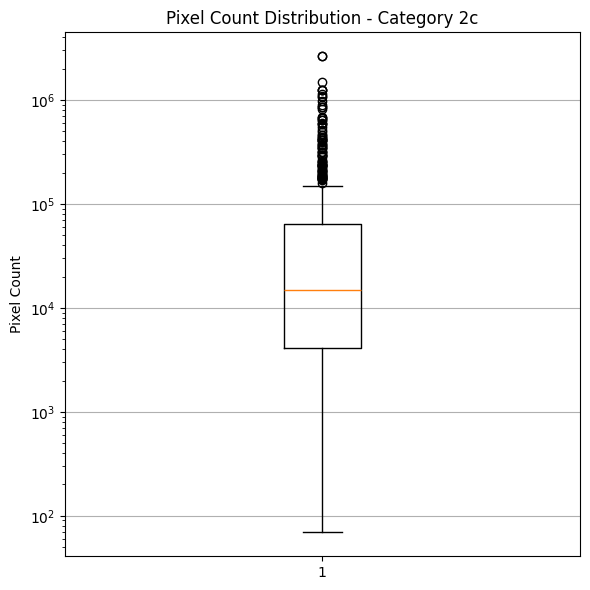

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure pixels are numeric
df_only_2c["pixels"] = pd.to_numeric(df_only_2c["pixels"])

# Statistics
print(df_only_2c["pixels"].describe())

# Box plot
plt.figure(figsize=(6, 6))

plt.boxplot(
    df_only_2c["pixels"],
    vert=True,
    patch_artist=False
)

plt.title("Pixel Count Distribution - Category 2c")
plt.ylabel("Pixel Count")

# Use log scale because pixel counts are usually highly skewed
plt.yscale("log")

plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [31]:
# Ensure pixels are numeric
df_only_2c["pixels"] = pd.to_numeric(df_only_2c["pixels"])

# Calculate Q1 and Q3
q1 = df_only_2c["pixels"].quantile(0.25)
q3 = df_only_2c["pixels"].quantile(0.75)

# Keep only values inside the box
df_only_2c_good = df_only_2c[
    (df_only_2c["pixels"] >= q1) &
    (df_only_2c["pixels"] <= q3)
].copy()

# Verify
print("df_only_2c_good:")
print(f"  rows  : {len(df_only_2c_good)}")
print(f"  scans : {df_only_2c_good['name'].nunique()}")

display(df_only_2c_good.head())

df_only_2c_good:
  rows  : 268
  scans : 218


,split,name,index,findings,entity_counts,pixels,categories
68,train,train_1676_a_2.nii.gz,0,Nodular ground-glass opacities in the peripher...,3,44381,2c
155,train,train_1850_a_1.nii.gz,0,Nodular ground-glass opacities in the lower lo...,3,40872,2c
169,train,train_1823_a_2.nii.gz,0,Nodular patchy ground-glass opacities in both ...,3,14553,2c
211,train,train_1823_b_2.nii.gz,0,Subpleural localized ground glass opacities in...,3,22742,2c
212,train,train_1823_b_2.nii.gz,1,More prominent ground glass opacities in the r...,2,20950,2c


count      268.000000
mean     20907.738806
std      15616.226211
min       4181.000000
25%       8289.500000
50%      14857.000000
75%      29001.750000
max      63936.000000
Name: pixels, dtype: float64


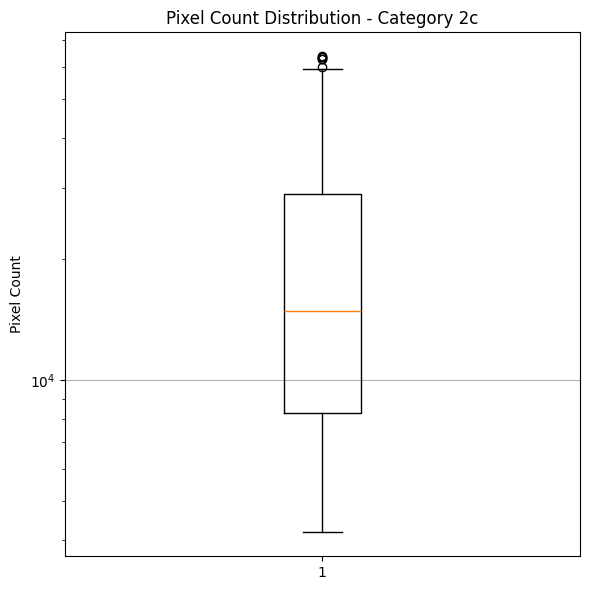

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure pixels are numeric
df_only_2c_good["pixels"] = pd.to_numeric(df_only_2c_good["pixels"])

# Statistics
print(df_only_2c_good["pixels"].describe())

# Box plot
plt.figure(figsize=(6, 6))

plt.boxplot(
    df_only_2c_good["pixels"],
    vert=True,
    patch_artist=False
)

plt.title("Pixel Count Distribution - Category 2c")
plt.ylabel("Pixel Count")

# Use log scale because pixel counts are usually highly skewed
plt.yscale("log")

plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [33]:
# Ensure pixels are numeric
df_only_2c_good["pixels"] = pd.to_numeric(df_only_2c_good["pixels"])

# Calculate Q1 and Q3
q1 = df_only_2c_good["pixels"].quantile(0.25)
q3 = df_only_2c_good["pixels"].quantile(0.75)

# Keep only values inside the box
df_only_2c_good = df_only_2c_good[
    (df_only_2c_good["pixels"] >= q1) &
    (df_only_2c_good["pixels"] <= q3)
].copy()

# Verify
print("df_only_2c_good:")
print(f"  rows  : {len(df_only_2c_good)}")
print(f"  scans : {df_only_2c_good['name'].nunique()}")

display(df_only_2c_good.head())

df_only_2c_good:
  rows  : 134
  scans : 118


,split,name,index,findings,entity_counts,pixels,categories
169,train,train_1823_a_2.nii.gz,0,Nodular patchy ground-glass opacities in both ...,3,14553,2c
211,train,train_1823_b_2.nii.gz,0,Subpleural localized ground glass opacities in...,3,22742,2c
212,train,train_1823_b_2.nii.gz,1,More prominent ground glass opacities in the r...,2,20950,2c
249,train,train_1760_a_2.nii.gz,1,Ground-glass opacities more prominently in lef...,1,25275,2c
297,train,train_1987_b_1.nii.gz,0,Patchy ground-glass opacities in both lungs,3,14397,2c


In [34]:
import json
import numpy as np


def convert_to_python(obj):
    """Convert numpy types to native Python types for JSON serialization."""
    if isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


dataset = {
    "train": []
}


for scan_name, group in df_only_2c_good.groupby("name"):

    entry = {
        "name": scan_name,
        "findings": {},
        "entity_counts": {},
        "pixels": {},
        "categories": {},
    }

    for idx, (_, row) in enumerate(group.iterrows()):

        idx = str(idx)

        entry["findings"][idx] = row["findings"]
        entry["entity_counts"][idx] = convert_to_python(row["entity_counts"])
        entry["pixels"][idx] = convert_to_python(row["pixels"])
        entry["categories"][idx] = row["categories"]
    dataset["train"].append(entry)


# Save JSON
output_path = "dataset_2c.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(
        dataset,
        f,
        indent=4,
        ensure_ascii=False
    )


print(f"Saved {len(dataset['train'])} scans to {output_path}")

Saved 118 scans to dataset_2c.json


In [12]:
# import json
# from pathlib import Path
# from collections import defaultdict

# import nibabel as nib
# import numpy as np
# import pandas as pd
# from tqdm import tqdm

# # ============================================================
# # Paths
# # ============================================================

# json_path = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2b_2c.json"

# ct_root = Path("/home/chest_ct/code/data/data_volumes/dataset/train_fixed")
# seg_root = Path("/home/chest_ct/code/data/segmentations/segmentations")

# output_dir = Path("./hu_histograms")
# output_dir.mkdir(exist_ok=True)

# # ============================================================
# # Histogram configuration
# # ============================================================

# HU_MIN = -1000
# HU_MAX = 1000

# # 1-HU bins:
# # [-1000,-999), [-999,-998), ...
# bins = np.arange(HU_MIN, HU_MAX + 1)

# # category -> histogram counts
# category_histograms = defaultdict(
#     lambda: np.zeros(len(bins) - 1, dtype=np.int64)
# )

# # ============================================================
# # Load dataset
# # ============================================================

# with open(json_path, "r") as f:
#     dataset = json.load(f)

# all_cases = dataset["train"] + dataset["val"]
# print(f"Total scans: {len(all_cases)}")

# # ============================================================
# # Process scans
# # ============================================================

# for case in tqdm(all_cases):

#     scan_name = case["name"]

#     ct_path = ct_root / scan_name
#     seg_path = seg_root / scan_name

#     if not ct_path.exists():
#         print(f"[Missing CT] {ct_path}")
#         continue

#     if not seg_path.exists():
#         print(f"[Missing Seg] {seg_path}")
#         continue

#     # --------------------------------------------------------
#     # Load CT
#     # --------------------------------------------------------

#     ct = nib.load(str(ct_path)).get_fdata().astype(np.float32)

#     # --------------------------------------------------------
#     # Load mask
#     # --------------------------------------------------------

#     seg = nib.load(str(seg_path)).get_fdata()

#     # expected shape:
#     # F x H x W x D
#     if seg.ndim != 4:
#         print(f"[Unexpected mask shape] {scan_name}: {seg.shape}")
#         continue

#     num_findings = seg.shape[0]

#     # --------------------------------------------------------
#     # Iterate findings
#     # --------------------------------------------------------

#     for finding_idx in range(num_findings):

#         key = str(finding_idx)

#         if key not in case["categories"]:
#             continue

#         category = case["categories"][key]

#         finding_mask = seg[finding_idx] > 0

#         if not np.any(finding_mask):
#             continue

#         hu_values = ct[finding_mask]

#         hist, _ = np.histogram(
#             hu_values,
#             bins=bins
#         )

#         category_histograms[category] += hist

# # ============================================================
# # Save histograms
# # ============================================================

# for category, counts in category_histograms.items():

#     df = pd.DataFrame({
#         "hu_bin_left": bins[:-1],
#         "hu_bin_right": bins[1:],
#         "count": counts
#     })

#     out_path = output_dir / f"{category}_histogram.csv"

#     df.to_csv(out_path, index=False)

#     print(
#         f"Saved {category}: "
#         f"{counts.sum():,} voxels -> {out_path}"
#     )

In [13]:
print("after adding 2d large findings")
df_common_with_2d_large = pd.concat(
    [df_common_scans, df_shortlisted_2d_large],
    ignore_index=True
).copy()

category_counts = (
    df_common_with_2d_large["categories"]
    .value_counts()
    .sort_index()
)

print(category_counts)

print("after adding 1c findings")
df_common_with_1c = pd.concat(
    [df_common_with_2d_large, df_shortlisted_1c],
    ignore_index=True
).copy()

category_counts = (
    df_common_with_1c["categories"]
    .value_counts()
    .sort_index()
)

print(category_counts)

after adding 2d large findings
categories
1c      7
2b    212
2c    309
2d     95
Name: count, dtype: int64
after adding 1c findings
categories
1c    173
2b    268
2c    352
2d     95
Name: count, dtype: int64


            count           mean            std    min       25%      50%  \
categories                                                                  
1c          173.0  269068.144509  915479.979256  101.0   2850.00  12213.0   
2b          268.0   50074.544776  132309.576820  413.0  10509.75  19223.5   
2c          352.0   37573.295455   78603.024251  157.0   9725.75  18936.0   
2d           95.0   81606.894737  225546.497309   59.0   3582.50   7317.0   

                  75%        max  
categories                        
1c          122196.00  8786708.0  
2b           45246.00  1664061.0  
2c           40023.25   753775.0  
2d           24585.00  1098312.0  


<Figure size 800x600 with 0 Axes>

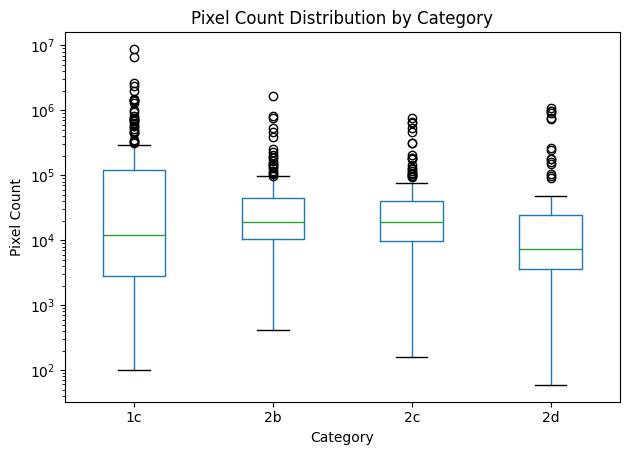

In [14]:
import matplotlib.pyplot as plt

# Ensure pixels are numeric
df_common_with_1c["pixels"] = pd.to_numeric(df_common_with_1c["pixels"])

# Plot
plt.figure(figsize=(8, 6))

df_common_with_1c.boxplot(
    column="pixels",
    by="categories",
    grid=False
)

stats = (
    df_common_with_1c
    .groupby("categories")["pixels"]
    .describe()
)

print(stats)

plt.title("Pixel Count Distribution by Category")
plt.suptitle("")  # Remove the automatic pandas subtitle
plt.xlabel("Category")
plt.ylabel("Pixel Count")

# Uncomment if the distributions are highly skewed
plt.yscale("log")

plt.tight_layout()
plt.show()

In [15]:
scan_counts = (
    df_common_with_1c
    .groupby("categories")["name"]
    .nunique()
    .reset_index(name="num_scans")
)

print(scan_counts)

  categories  num_scans
0         1c        162
1         2b        196
2         2c        287
3         2d         51


In [16]:
df_common_with_1c["name"].unique().shape[0]

522

/tmp/ipykernel_1748504/980394941.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


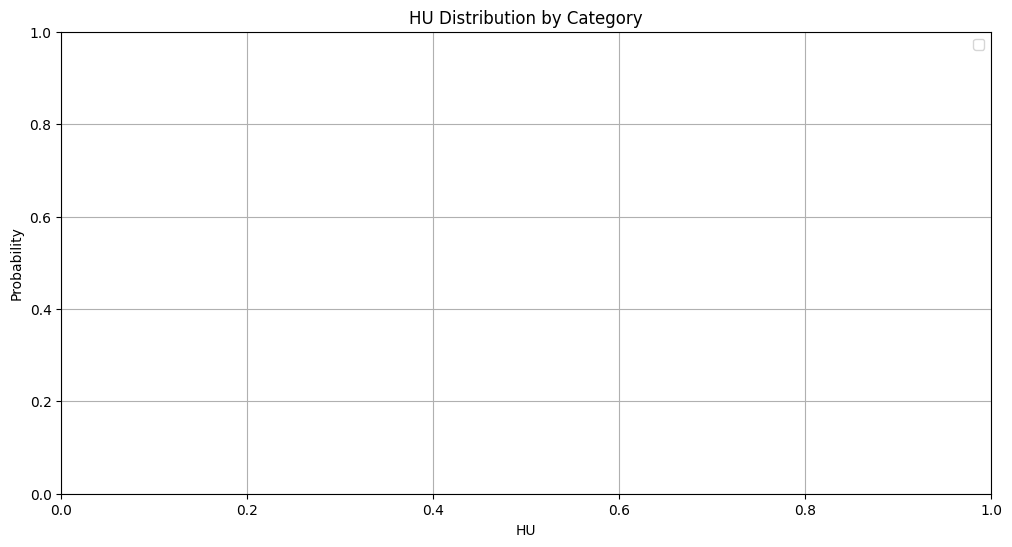

In [17]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

hist_dir = Path("./hu_histograms")

plt.figure(figsize=(12, 6))

for csv_file in sorted(hist_dir.glob("*_histogram.csv")):

    category = csv_file.stem.replace("_histogram", "")

    df = pd.read_csv(csv_file)

    x = df["hu_bin_left"].values
    y = df["count"].values

    y = y / y.sum()  # normalize

    plt.plot(x, y, label=category)

plt.xlabel("HU")
plt.ylabel("Probability")
plt.title("HU Distribution by Category")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
import json

import pandas as pd

with open("/home/chest_ct/code/data/rexgrounding-ct/dataset_2_final.json", "r") as f:
    data = json.load(f)

rows = []

for split, samples in data.items():
    for sample in samples:
        for idx in sample["findings"]:
            rows.append({
                "split": split,
                "name": sample["name"],
                "index": int(idx),
                "findings": sample["findings"][idx],
                "entity_counts": sample["entity_counts"][idx],
                "pixels": sample["pixels"][idx],
                "categories": sample["categories"][idx],
            })

df = pd.DataFrame(rows)

df.head()

,split,name,index,findings,entity_counts,pixels,categories
0,train,train_10097_a_1.nii.gz,0,Mild subpleural ground glass densities in both...,1,8708,2c
1,train,train_10144_a_1.nii.gz,0,Ground-glass opacities with interlobular septa...,3,19665,2c
2,train,train_10218_a_1.nii.gz,0,Non-specific ground-glass opacities in the pos...,1,11933,2c
3,train,train_10353_a_2.nii.gz,0,Subpleural patchy ground glass opacities in bo...,3,21347,2c
4,train,train_10381_b_2.nii.gz,0,Scattered ground glass opacities in both lungs...,3,13465,2c


In [38]:
scan_counts = (
    df
    .groupby("categories")
    .nunique()
)

print(scan_counts)

            split  name  index  findings  entity_counts  pixels
categories                                                     
2c              2   137      4       157              6     158
2d              1    51      6        94              6      90


In [41]:
print(
    df[
        (df["split"] == "train") &
        (df["categories"] == "2c")
    ]["categories"].value_counts()
)

categories
2c    150
Name: count, dtype: int64


In [43]:
import numpy as np

path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/previous/unified_train_normal.npz"

data = np.load(path, allow_pickle=True)

for key in data.files:
    arr = data[key]
    print(
        f"{key}: "
        f"shape={getattr(arr, 'shape', None)}, "
        f"dtype={getattr(arr, 'dtype', type(arr))}"
    )

X: shape=(1728, 67766), dtype=float64
H: shape=(67766,), dtype=int64
scan_ids: shape=(67766,), dtype=object
coords: shape=(67766, 3), dtype=int64


In [44]:
import json

file1 = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2_final.json"
file2 = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2_last.json"


def get_normal_scans(path):
    with open(path, "r") as f:
        data = json.load(f)

    normal_scans = set()

    for split in ["train", "test"]:
        for item in data.get(split, []):
            if item.get("categories", {}) == {}:
                normal_scans.add(item["name"])

    return normal_scans


norm1 = get_normal_scans(file1)
norm2 = get_normal_scans(file2)

print("dataset_2_final normal scans:", len(norm1))
print("dataset_2_last normal scans :", len(norm2))

print("\nCommon normal scans:", len(norm1 & norm2))
print("Only in dataset_2_final:", len(norm1 - norm2))
print("Only in dataset_2_last :", len(norm2 - norm1))

print("\n--- Only in dataset_2_final ---")
for s in sorted(norm1 - norm2):
    print(s)

print("\n--- Only in dataset_2_last ---")
for s in sorted(norm2 - norm1):
    print(s)

dataset_2_final normal scans: 121
dataset_2_last normal scans : 121

Common normal scans: 121
Only in dataset_2_final: 0
Only in dataset_2_last : 0

--- Only in dataset_2_final ---

--- Only in dataset_2_last ---


In [1]:
import json

def get_normal_by_split(path):
    with open(path, "r") as f:
        data = json.load(f)

    return {
        split: {
            item["name"]
            for item in data.get(split, [])
            if item.get("categories", {}) == {}
        }
        for split in ["train", "test"]
    }

d1 = get_normal_by_split("/home/chest_ct/code/data/rexgrounding-ct/dataset_2_final.json")
d2 = get_normal_by_split("/home/chest_ct/code/data/rexgrounding-ct/dataset_2_final_normal_reduced.json")

for split in ["train", "test"]:
    print(f"\n=== {split.upper()} ===")
    print("Final normals:", len(d1[split]))
    print("Last normals :", len(d2[split]))
    print("Common       :", len(d1[split] & d2[split]))
    print("Only final   :", len(d1[split] - d2[split]))
    print("Only last    :", len(d2[split] - d1[split]))


=== TRAIN ===
Final normals: 100
Last normals : 19
Common       : 19
Only final   : 81
Only last    : 0

=== TEST ===
Final normals: 21
Last normals : 21
Common       : 21
Only final   : 0
Only last    : 0
